# Figure 1: robustness of the Wasserstein median

This notebook reproduces the two-dimensional Gaussian contamination example in Figure 1.
It generates every input and recomputes both estimators; no data files, manuscript files,
or network access are needed after installing the dependencies.

- **(a)** Six signal Gaussians and four displaced noise Gaussians, represented by unfilled 95% probability ellipses.
- **(b)** Their equally weighted Wasserstein barycenter and numerical Wasserstein median, with the target $\mathcal N(0,I_2)$.
- **(c)** Wasserstein errors to that target as the total noise weight increases from 0% to 49%.

Choose **Restart Kernel and Run All Cells** to reproduce the example. The saved outputs include the figure.
By default, running the notebook creates no additional files in this folder.

## 1. Dependencies and rendering

The checked environment uses Python 3.11.15, NumPy 2.3.5, Matplotlib 3.10.8, and
threadpoolctl 3.6.0. Installation instructions are in `README.md`.

`RENDER_MODE = "auto"` uses the manuscript's LaTeX typography when `pdflatex`,
`kpsewhich`, and `pdftocairo` are on `PATH`, with the TeX packages `pgf` and `stix` installed.
Otherwise it uses Matplotlib's bundled STIX fonts. Set `"tex"` to require the
manuscript renderer, or `"matplotlib"` for a portable preview. The numerical
calculations, panel geometry, and colors are identical in both modes.

In [1]:
import io
import platform
import shutil
import subprocess
import tempfile
import time
from importlib.metadata import version
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse
from matplotlib.ticker import MaxNLocator
from threadpoolctl import threadpool_limits

RENDER_MODE = "auto"  # "auto", "tex", or "matplotlib"
SEED = 20260925
SIGNAL_COUNT = 6
NOISE_COUNT = 4
OBSERVATIONS_PER_SIGNAL = 100
FRACTIONS = np.arange(50) / 100
ILLUSTRATIVE_FRACTION = 0.40

print(f"Python {platform.python_version()}")
for package in ("numpy", "matplotlib", "threadpoolctl"):
    print(f"{package} {version(package)}")

Python 3.11.15
numpy 2.4.6
matplotlib 3.11.0
threadpoolctl 3.6.0


## 2. Generate the ten Gaussian laws

For each signal law, draw 100 independent observations from $\mathcal N(0,I_2)$,
then use their empirical mean and unbiased sample covariance (denominator 99).
The four noise covariances are $R(\theta)\operatorname{diag}(\lambda_1,\lambda_2)R(\theta)^\mathsf T$,
where $R(\theta)$ rotates counterclockwise and the eigenvalues below are **variances**.

| Noise law | Mean | Rotation | Covariance eigenvalues |
|---|---|---|---|
| 1 | (5, 5.5) | 25° | (4, 0.36) |
| 2 | (6.5, 5) | 65° | (6.25, 0.49) |
| 3 | (5.5, 7) | 110° | (4.84, 0.25) |
| 4 | (7.5, 7.5) | 150° | (5.76, 0.64) |

All ten laws remain fixed throughout the experiment. At contamination weight $\varepsilon$,
each signal has weight $(1-\varepsilon)/6$ and each noise law has weight $\varepsilon/4$.
Thus panel (b) uses **40%** contamination, when every law has weight 0.1.
Panel (c) varies the weights, not the number of noise laws, and includes the **49%** endpoint.

In [2]:
noise_means = np.array([[5.0, 5.5], [6.5, 5.0], [5.5, 7.0], [7.5, 7.5]])
noise_angles = np.array([25.0, 65.0, 110.0, 150.0])
noise_eigenvalues = np.array([[4.0, 0.36], [6.25, 0.49], [4.84, 0.25], [5.76, 0.64]])

rng = np.random.default_rng(SEED)
signal_samples = rng.standard_normal((SIGNAL_COUNT, OBSERVATIONS_PER_SIGNAL, 2))
signal_means = signal_samples.mean(axis=1)
signal_covariances = np.array([
    np.cov(sample, rowvar=False, ddof=1) for sample in signal_samples
])
noise_covariances = []
for angle, eigenvalues in zip(noise_angles, noise_eigenvalues):
    theta = np.deg2rad(angle)
    rotation = np.array([[np.cos(theta), -np.sin(theta)],
                         [np.sin(theta), np.cos(theta)]])
    noise_covariances.append(rotation @ np.diag(eigenvalues) @ rotation.T)

means = np.vstack([signal_means, noise_means])
covariances = np.concatenate([signal_covariances, noise_covariances])
assert means.shape == (10, 2) and covariances.shape == (10, 2, 2)
assert np.linalg.eigvalsh(covariances).min() > 0


def contamination_weights(epsilon):
    if not 0 <= epsilon <= 1:
        raise ValueError("The total noise weight must be between zero and one.")
    return np.r_[np.full(SIGNAL_COUNT, (1 - epsilon) / SIGNAL_COUNT),
                 np.full(NOISE_COUNT, epsilon / NOISE_COUNT)]

## 3. Gaussian Wasserstein calculations

For Gaussian laws, the squared quadratic Wasserstein distance is

$$
W_2^2\bigl(\mathcal N(m,S),\mathcal N(n,T)\bigr)
=\|m-n\|^2+\operatorname{tr}\!\left(S+T-2(S^{1/2}TS^{1/2})^{1/2}\right).
$$

The implementation evaluates the equivalent Procrustes formula for the covariance term,
which avoids cancellation near coincident laws. It uses full positive-definite
covariances, with no support grid, entropic regularization, or eigenvalue flooring.
Zero-weight inputs are excluded before fitting.

In [3]:
def sym(A):
    return (A + np.swapaxes(A, -1, -2)) / 2


def root_spd(A):
    A = sym(np.asarray(A, dtype=float))
    values, vectors = np.linalg.eigh(A)
    if not np.isfinite(values).all() or np.min(values) <= 0:
        raise ValueError("A strictly positive-definite covariance is required")
    return (vectors * np.sqrt(values)[..., None, :]) @ np.swapaxes(vectors, -1, -2)


def distances(mean, covariance, means, covariances):
    """Stable exact Gaussian W2 distances, evaluated in floating point."""
    a = root_spd(covariance)
    b = root_spd(covariances)
    u, _, vh = np.linalg.svd(np.swapaxes(b, -1, -2) @ a)
    rotation = u @ vh
    discrepancy = a - b @ rotation
    covariance_cost = np.sum(discrepancy ** 2, axis=(-2, -1))
    return np.sqrt(np.sum((means - mean) ** 2, axis=-1) + covariance_cost)


def normalize_inputs(means, covariances, weights):
    means = np.asarray(means, dtype=float)
    covariances = np.asarray(covariances, dtype=float)
    weights = np.asarray(weights, dtype=float)
    if means.shape != (len(weights), 2) or covariances.shape != (len(weights), 2, 2):
        raise ValueError("Expected Gaussian inputs in dimension two")
    if not np.isfinite(weights).all() or np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError("Weights must be nonnegative with positive sum")
    active = weights > 0
    means, covariances, weights = means[active], covariances[active], weights[active]
    root_spd(covariances)
    weights = weights / weights.sum()
    return means, covariances, weights


def standard_normal_error(mean, covariance):
    """Exact W2 distance to N(0,I), with stable covariance term."""
    return float(np.sqrt(mean @ mean + np.sum((root_spd(covariance) - np.eye(2)) ** 2)))

### Barycenter

The barycenter minimizes $\sum_i\pi_i W_2^2(\nu,\mu_i)$.
Its mean is $\sum_i\pi_i m_i$. We compute its covariance by the fixed-point
iteration of Álvarez-Esteban et al. (2016), stopping when the Frobenius norm of
the weighted optimal-transport-map average minus $I_2$ is at most $10^{-11}$.
A failed convergence check raises an error instead of returning an unchecked result.

In [4]:
def barycenter(means, covariances, weights, init_covariance=None,
               tolerance=1e-11, max_iterations=1000):
    means, covariances, weights = normalize_inputs(means, covariances, weights)
    mean = weights @ means
    covariance = (np.einsum("i,ijk->jk", weights, covariances)
                  if init_covariance is None else np.array(init_covariance, copy=True))
    residual_history = []
    for iteration in range(max_iterations + 1):
        root = root_spd(covariance)
        inverse = np.linalg.inv(root)
        crossed = root_spd(root @ covariances @ root)
        average = np.einsum("i,ijk->jk", weights, crossed)
        transport_average = sym(inverse @ average @ inverse)
        residual = float(np.linalg.norm(transport_average - np.eye(2), ord="fro"))
        residual_history.append(residual)
        if residual <= tolerance:
            objective = float(weights @ distances(mean, covariance, means, covariances) ** 2)
            return mean, covariance, dict(converged=True, iterations=iteration,
                fixed_point_residual=residual, objective=objective,
                minimum_eigenvalue=float(np.linalg.eigvalsh(covariance)[0]))
        covariance = sym(inverse @ average @ average @ inverse)
    raise RuntimeError(f"Barycenter failed fixed-point residual check: {residual}")

### Median

The median objective is $\sum_i\pi_i W_2(\nu,\mu_i)$, with **unsquared** distances.
Each majorization-minimization (MM) step computes a Gaussian barycenter with
weights proportional to $\pi_i/W_2(\nu,\mu_i)$.

We use three starts: the barycenter; the weighted mean and arithmetic covariance;
and the best input law moved 0.001 of the way toward the barycenter in mean and
covariance coordinates. The returned candidate has the lowest fitting objective
among these runs and all active input laws. The true target is never used for
initialization or candidate selection.

Each run requires three consecutive steps with Wasserstein movement at most
$10^{-8}$ and objective change at most $10^{-12}\max(1,F(\nu))$; the iteration cap
is 2,000. Distances at most $10^{-10}$ are recorded as input hits rather than
regularized. All runs in this example converge without input hits.

The displayed median is a numerical candidate. Multiple starts and these
diagnostics do not certify global optimality or uniqueness; compatibility of
the generated inputs is not assumed.

In [5]:
def run_mm(initial, means, covariances, weights, max_iterations=2000):
    mean, covariance = (np.array(x, copy=True) for x in initial)
    d = distances(mean, covariance, means, covariances)
    objective = float(weights @ d)
    history = [objective]
    traces = []
    stable = 0
    for iteration in range(1, max_iterations + 1):
        if d.min() <= 1e-10:
            return mean, covariance, dict(status="input_hit", iterations=iteration-1,
                objective=objective, objective_history=history, trace=traces)
        inner_weights = weights / d
        next_mean, next_covariance, info = barycenter(
            means, covariances, inner_weights, init_covariance=covariance)
        next_d = distances(next_mean, next_covariance, means, covariances)
        next_objective = float(weights @ next_d)
        if next_objective > objective + 1e-10 * max(1, abs(objective)):
            raise RuntimeError("Median MM objective increased beyond numerical tolerance")
        step = float(distances(mean, covariance, next_mean[None, :], next_covariance[None, :, :])[0])
        improvement = objective - next_objective
        traces.append(dict(iteration=iteration, objective=next_objective,
            improvement=improvement, step=step,
            inner_iterations=info["iterations"], inner_residual=info["fixed_point_residual"]))
        history.append(next_objective)
        stable = stable + 1 if (abs(improvement) <= 1e-12 * max(1, objective)
                               and step <= 1e-8) else 0
        mean, covariance, d, objective = next_mean, next_covariance, next_d, next_objective
        if stable >= 3:
            return mean, covariance, dict(status="objective_and_step_stable",
                iterations=iteration, objective=objective, objective_history=history, trace=traces)
    raise RuntimeError("Median MM reached its iteration cap")


def median(means, covariances, weights, barycenter_fit=None):
    means, covariances, weights = normalize_inputs(means, covariances, weights)
    if barycenter_fit is None:
        bm, bc, _ = barycenter(means, covariances, weights)
    else:
        bm, bc = barycenter_fit
    input_objectives = np.array([weights @ distances(m, c, means, covariances)
                                 for m, c in zip(means, covariances)])
    medoid = int(np.argmin(input_objectives))
    initializations = [
        (bm, bc),
        (weights @ means, np.einsum("i,ijk->jk", weights, covariances)),
        (.999 * means[medoid] + .001 * bm,
         .999 * covariances[medoid] + .001 * bc)]
    runs = [run_mm(initial, means, covariances, weights) for initial in initializations]
    objectives = [run[2]["objective"] for run in runs] + [float(input_objectives[medoid])]
    candidates = [(run[0], run[1]) for run in runs] + [(means[medoid], covariances[medoid])]
    selected = int(np.argmin(objectives))
    return *candidates[selected], dict(selected_candidate=selected,
        candidate_objectives=objectives, runs=[run[2] for run in runs],
        input_medoid_active_index=medoid, input_objectives=input_objectives.tolist(),
        global_optimality_certified=False)

## 4. Fit both estimators over the contamination curve

The plotted error is $W_2(\widehat\nu,\mathcal N(0,I_2))$, evaluated by
$\bigl(\|\widehat m\|^2+\|\widehat S^{1/2}-I_2\|_F^2\bigr)^{1/2}$.
There is no empirical clean reference or baseline subtraction. This is one
fixed-data illustration, not an average over repeated experiments.

In [6]:
result_names = ["barycenter_means", "barycenter_covariances", "median_means",
                "median_covariances", "barycenter_errors", "median_errors"]
results = {name: [] for name in result_names}
diagnostics = []
start = time.perf_counter()

with threadpool_limits(limits=1):
    for index, epsilon in enumerate(FRACTIONS):
        weights = contamination_weights(epsilon)
        bm, bc, bi = barycenter(means, covariances, weights)
        mm, mc, mi = median(means, covariances, weights, barycenter_fit=(bm, bc))
        fitted = (bm, bc, mm, mc, standard_normal_error(bm, bc),
                  standard_normal_error(mm, mc))
        for name, value in zip(result_names, fitted):
            results[name].append(value)
        diagnostics.append(dict(fraction=float(epsilon), barycenter=bi, median=mi))
        if index % 10 == 0 or index == len(FRACTIONS) - 1:
            print(f"Noise weight {epsilon:3.0%}: "
                  f"barycenter error = {fitted[-2]:.6f}, median error = {fitted[-1]:.6f}")

data = {name: np.array(values) for name, values in results.items()}
data.update(means=means, covariances=covariances, signal_samples=signal_samples,
            fractions=FRACTIONS)
print(f"Computed {len(FRACTIONS)} settings in {time.perf_counter() - start:.2f} seconds.")

Noise weight  0%: barycenter error = 0.046016, median error = 0.067419
Noise weight 10%: barycenter error = 0.907823, median error = 0.086364
Noise weight 20%: barycenter error = 1.781878, median error = 0.108248
Noise weight 30%: barycenter error = 2.656130, median error = 0.136432
Noise weight 40%: barycenter error = 3.530443, median error = 0.187069
Noise weight 49%: barycenter error = 4.317351, median error = 0.457239
Computed 50 settings in 1.73 seconds.


## 5. Reproduction checks

The following checks cover every fitted setting: positive-definite estimates,
converged barycenters and MM runs, MM descent, agreement across starts, and
finite nonnegative errors. Three rounded error pairs from the manuscript
experiment provide a separate reference check. Small floating-point differences
across platforms are expected. The reference values are used only for checking,
never for fitting or drawing the curves.

In [7]:
runs = [run for item in diagnostics for run in item["median"]["runs"]]
traces = [step for run in runs for step in run["trace"]]
assert len(runs) == 150
assert all(run["status"] == "objective_and_step_stable" for run in runs)
max_barycenter_residual = max(item["barycenter"]["fixed_point_residual"] for item in diagnostics)
max_inner_residual = max(step["inner_residual"] for step in traces)
max_mm_increase = max(0.0, max(-step["improvement"] for step in traces))
max_start_spread = max(np.ptp(item["median"]["candidate_objectives"][:3]) for item in diagnostics)
assert max_barycenter_residual <= 1e-11 and max_inner_residual <= 1e-11
assert max_mm_increase <= 1e-10 and max_start_spread < 1e-8
for method in ("barycenter", "median"):
    assert np.isfinite(data[f"{method}_means"]).all()
    assert np.linalg.eigvalsh(data[f"{method}_covariances"]).min() > 0
    assert np.isfinite(data[f"{method}_errors"]).all()
    assert (data[f"{method}_errors"] >= 0).all()

check_indices = [0, 40, 49]
reference_errors = np.array([[0.046016, 0.067419],
                             [3.530443, 0.187069],
                             [4.317351, 0.457239]])
computed_errors = np.column_stack([data["barycenter_errors"][check_indices],
                                   data["median_errors"][check_indices]])
np.testing.assert_allclose(computed_errors, reference_errors, atol=2e-6, rtol=0)

print(f"All {len(runs)} MM runs converged; maximum iterations: "
      f"{max(run['iterations'] for run in runs)}")
print(f"Largest barycenter residual: {max_barycenter_residual:.2e}")
print(f"Largest inner barycenter residual: {max_inner_residual:.2e}")
print(f"Largest MM objective increase: {max_mm_increase:.2e}")
print(f"Largest objective spread across starts: {max_start_spread:.2e}")
print("Reference error checks passed.")

rows = ["| Total noise weight | Barycenter error | Median error |",
        "|---|---:|---:|"]
for index in check_indices:
    rows.append(f"| {FRACTIONS[index]:.0%} | {data['barycenter_errors'][index]:.6f} "
                f"| {data['median_errors'][index]:.6f} |")
display(Markdown("\n".join(rows)))

All 150 MM runs converged; maximum iterations: 190
Largest barycenter residual: 9.82e-12
Largest inner barycenter residual: 9.99e-12
Largest MM objective increase: 8.88e-16
Largest objective spread across starts: 8.88e-16
Reference error checks passed.


| Total noise weight | Barycenter error | Median error |
|---|---:|---:|
| 0% | 0.046016 | 0.067419 |
| 40% | 3.530443 | 0.187069 |
| 49% | 4.317351 | 0.457239 |

## 6. Draw Figure 1

Both spatial panels use the same limits $[-3.5,13.3]$ and equal coordinate scales.
Each ellipse encloses 95% of its Gaussian's probability, with squared Mahalanobis
radius $\chi^2_{2,0.95}=-2\log(0.05)$. These are **probability ellipses**, not confidence
regions for estimated means. Signal and noise contours are unfilled with opacity 0.2.

The canvas is 164.6 mm wide and 2.65 inches high; each square plotting region is
34.41786 mm wide. The LaTeX mode retains the manuscript's 10-point type without
shrinking the labels along with the panels. PDF and PNG versions are generated
in memory or in an automatically removed temporary directory. Only the inline
PNG is stored in the notebook's saved outputs.

In [8]:
CHI2_95_DF2 = -2 * np.log(0.05)
COLORS = {
    "signal": "#56B4E9", "noise": "#E69F00", "barycenter": "#AA3377",
    "median": "#228833", "target": "#252525",
}



def probability_ellipse(ax, mean, covariance, color, linewidth=1.2,
                        linestyle="-", alpha=1.0, center=True, zorder=3,
                        fill=False):
    """Add an exact Gaussian 95% probability contour and its center."""
    eigvals, eigvecs = np.linalg.eigh(covariance)
    if not np.all(eigvals > 0):
        raise ValueError("The Gaussian covariance must be positive definite.")
    rotation = np.degrees(np.arctan2(eigvecs[1, 1], eigvecs[0, 1]))
    radii = np.sqrt(CHI2_95_DF2 * eigvals)
    patch = Ellipse(mean, width=2 * radii[1], height=2 * radii[0],
                    angle=rotation, fill=fill, facecolor=color, edgecolor=color,
                    linewidth=linewidth, linestyle=linestyle,
                    alpha=alpha, zorder=zorder)
    ax.add_patch(patch)
    if center:
        ax.plot(*mean, marker="o", markersize=2.4, color=color,
                alpha=alpha, linewidth=0, zorder=zorder + .1)
    return patch


def style_spatial_axis(ax, limits, ticks):
    ax.set(xlim=limits, ylim=limits, aspect="equal", adjustable="box")
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(length=2.5, pad=3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axhline(0, color="#e0e0e0", linewidth=.6, zorder=0)
    ax.axvline(0, color="#e0e0e0", linewidth=.6, zorder=0)


def legend_handle(color, linestyle="-", marker=None, linewidth=1.5, alpha=1):
    return Line2D([0], [0], color=color, linestyle=linestyle,
                  marker=marker, markersize=3.2, linewidth=linewidth, alpha=alpha)

In [9]:
def make_figure(data):
    fraction = ILLUSTRATIVE_FRACTION
    j = int(np.argmin(abs(data["fractions"] - fraction)))
    if not np.isclose(data["fractions"][j], fraction, rtol=0, atol=1e-12):
        raise ValueError("The illustration fraction was not computed.")
    n_signal, n_noise = SIGNAL_COUNT, NOISE_COUNT
    width = 164.6 / 25.4
    height = 2.65
    fig = plt.figure(figsize=(width, height))
    # Shrink each square plotting region by 15%, preserving the full-width
    # canvas and manuscript-sized type rather than scaling the whole figure.
    panel_width = .246 * .85
    panel_height = width * panel_width / height
    axes = [fig.add_axes([center - panel_width / 2, .37,
                          panel_width, panel_height])
            for center in [.194, .523, .852]]

    ax = axes[0]
    for i, (mean, covariance) in enumerate(zip(data["means"], data["covariances"])):
        kind = "signal" if i < n_signal else "noise"
        probability_ellipse(ax, mean, covariance, COLORS[kind],
                            linewidth=.95, alpha=.2, fill=False, center=False)
    # Input mean markers have the same opacity as their unfilled contours.
    ax.scatter(data["means"][:, 0], data["means"][:, 1],
               s=8, c=[COLORS["signal"] if i < n_signal else COLORS["noise"]
                        for i in range(n_signal + n_noise)],
               edgecolors="none", alpha=.2, zorder=6)
    # The fourth noise ellipse extends to x=12.68, so the requested initial
    # range ending at 12 would clip a genuine probability contour.
    style_spatial_axis(ax, (-3.5, 13.3), [0, 5, 10])
    ax.set_title("(a)", pad=8)
    ax.legend([legend_handle(COLORS["signal"], alpha=.2),
               legend_handle(COLORS["noise"], alpha=.2)],
              ["Signal", "Noise"], loc="upper center", bbox_to_anchor=(.5, -.17),
              frameon=False, handlelength=1.6, handletextpad=.5,
              borderaxespad=0, labelspacing=.4)

    ax = axes[1]
    probability_ellipse(ax, np.zeros(2), np.eye(2), COLORS["target"],
                        linestyle=(0, (4, 2.3)), linewidth=1.0,
                        center=False, zorder=2)
    probability_ellipse(ax, data["barycenter_means"][j],
                        data["barycenter_covariances"][j], COLORS["barycenter"],
                        linewidth=1.55, zorder=3)
    probability_ellipse(ax, data["median_means"][j],
                        data["median_covariances"][j], COLORS["median"],
                        linewidth=1.55, zorder=4)
    style_spatial_axis(ax, (-3.5, 13.3), [0, 5, 10])
    ax.set_title("(b)", pad=8)
    ax.legend([legend_handle(COLORS["barycenter"]),
               legend_handle(COLORS["median"]),
               legend_handle(COLORS["target"], "--", linewidth=1.0)],
              ["Barycenter", "Median", r"$\mathcal{N}(0,I_2)$"],
              loc="upper center", bbox_to_anchor=(.5, -.17), frameon=False,
              handlelength=1.6, handletextpad=.5, borderaxespad=0, labelspacing=.4)

    ax = axes[2]
    percentages = 100 * data["fractions"]
    ax.axvline(100 * fraction, color="#777777", linestyle=":", linewidth=.9, zorder=0)
    for method, linestyle, marker in [("barycenter", "-", "o"), ("median", "--", "s")]:
        ax.plot(percentages, data[f"{method}_errors"], color=COLORS[method],
                linewidth=1.55, linestyle=linestyle, marker=marker,
                markevery=[0, 10, 20, 30, 40, len(percentages) - 1],
                markersize=3, markeredgewidth=.65, zorder=3)
    ax.set_title("(c)", pad=8)
    ax.set_xlabel(r"Noise weight (\%)", labelpad=5)
    ax.set_ylabel(r"$W_2$ error", labelpad=4)
    ax.set_xlim(-1, 50)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 25, 49])
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=3))
    ax.tick_params(length=2.5, pad=3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e3e3e3", linewidth=.5)
    ax.set_axisbelow(True)
    ax.legend([legend_handle(COLORS["barycenter"], marker="o"),
               legend_handle(COLORS["median"], "--", marker="s")],
              ["Barycenter", "Median"], loc="upper center",
              bbox_to_anchor=(.5, -.40), frameon=False, handlelength=1.6,
              handletextpad=.5, borderaxespad=0, labelspacing=.4)

    return fig

Renderer: Matplotlib / portable STIX preview


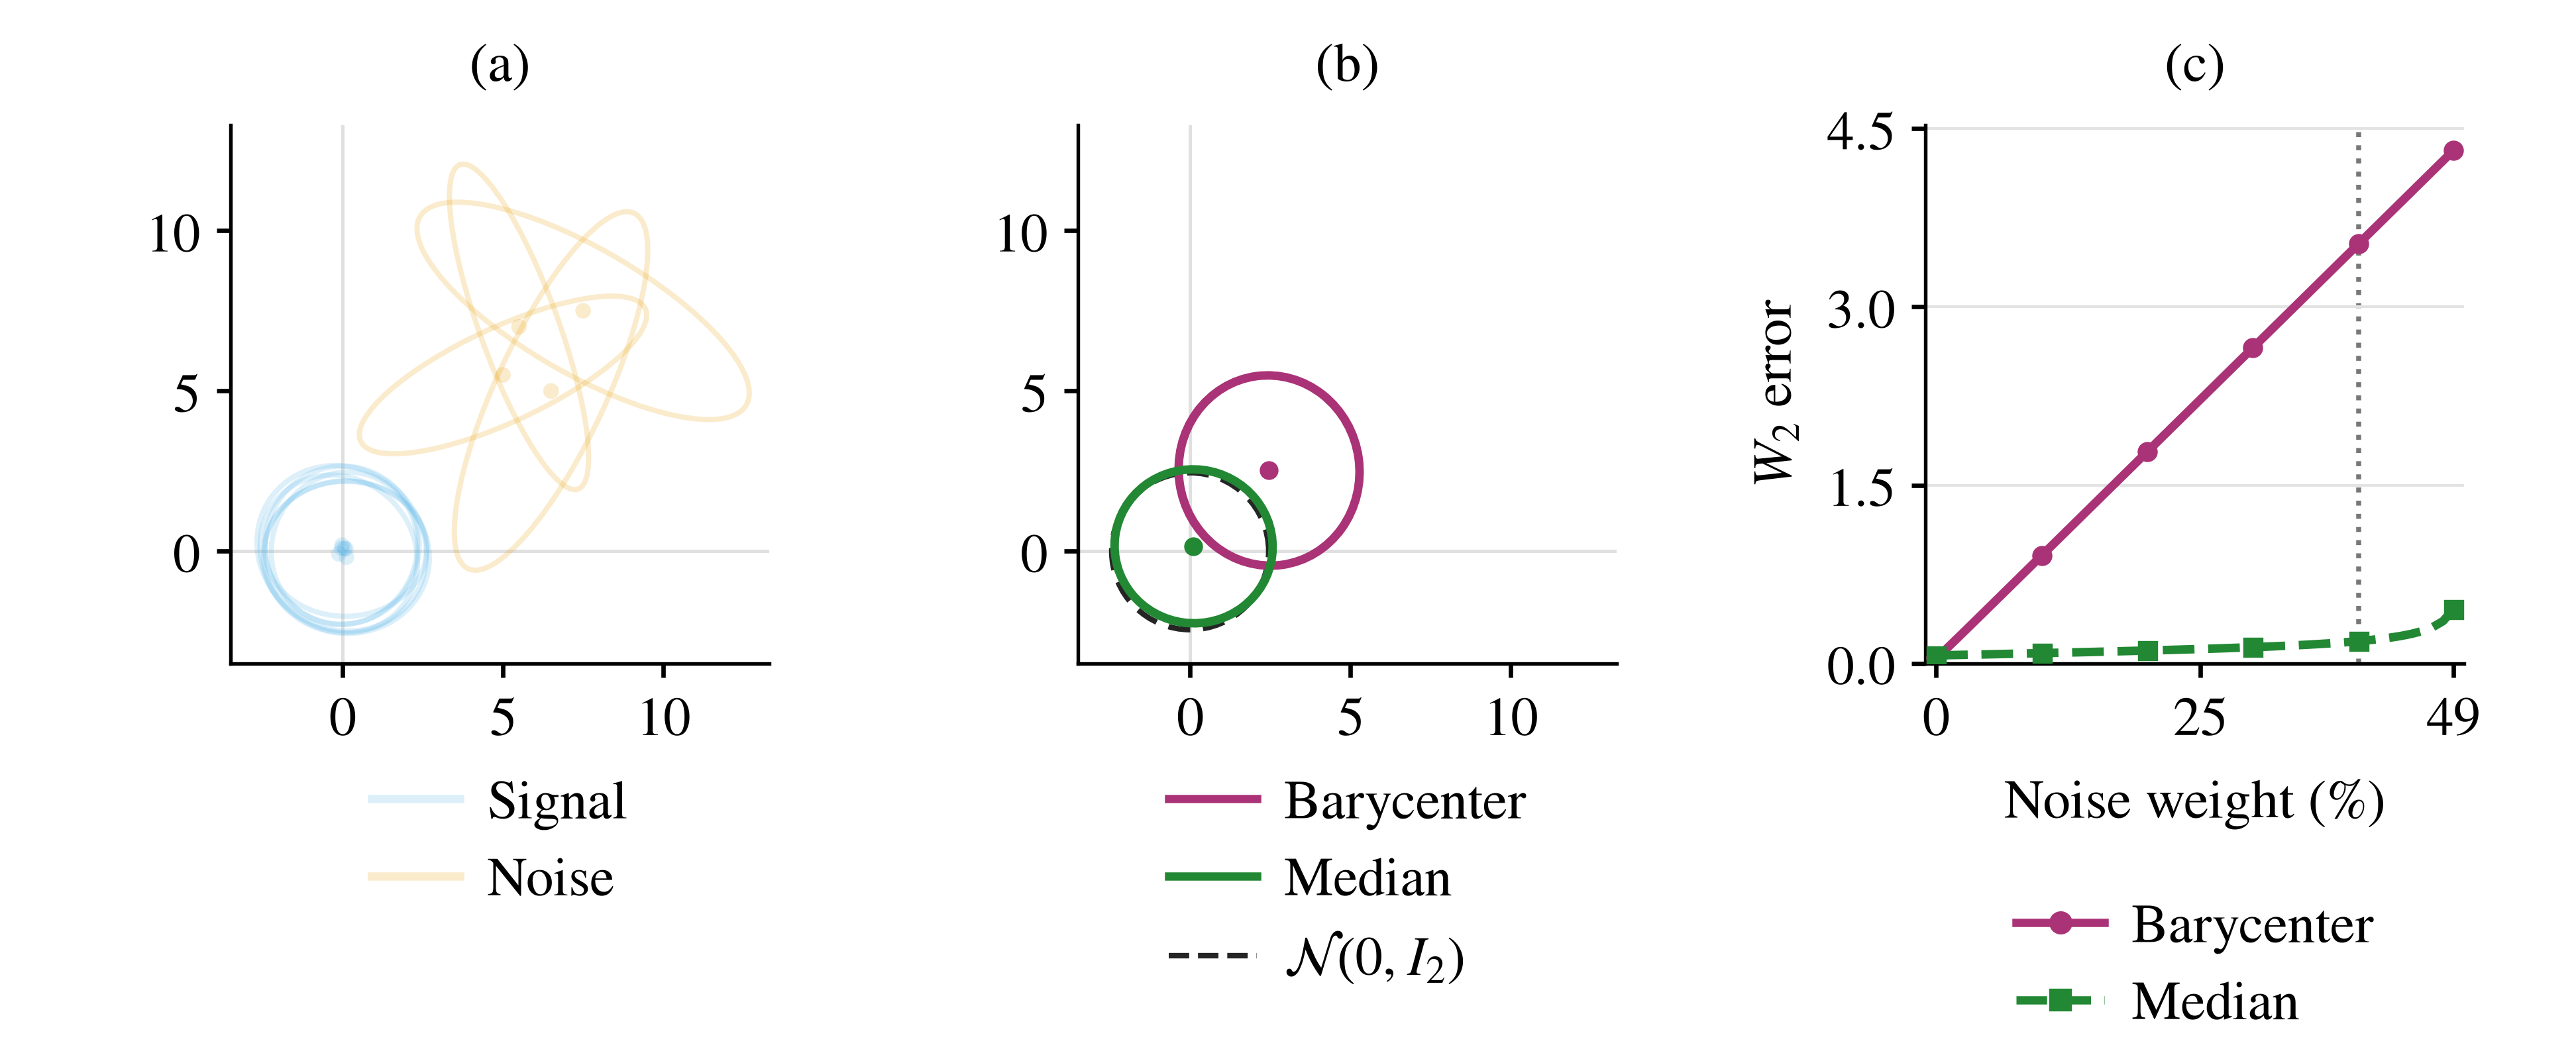

In [10]:
def choose_renderer(mode):
    if mode not in {"auto", "tex", "matplotlib"}:
        raise ValueError("RENDER_MODE must be 'auto', 'tex', or 'matplotlib'.")
    if mode == "matplotlib":
        return False
    programs = {name: shutil.which(name) for name in ("pdflatex", "kpsewhich", "pdftocairo")}
    ready = all(programs.values())
    if ready:
        ready = all(
            subprocess.run([programs["kpsewhich"], package], capture_output=True,
                           text=True, check=False).returncode == 0
            for package in ("pgf.sty", "stix.sty")
        )
    if mode == "tex" and not ready:
        raise RuntimeError("LaTeX rendering needs pdflatex, kpsewhich, pdftocairo, "
                           "and the pgf/stix TeX packages. See README.md, "
                           "or set RENDER_MODE = 'matplotlib'.")
    return ready


def render_figure(data, mode="auto"):
    use_tex = choose_renderer(mode)
    # Matplotlib uses PDF points; PGF converts its requested size to TeX points.
    font_size = 10.0 if use_tex else 10.0 * 72.0 / 72.27
    style = {
        "font.family": "serif", "font.serif": ["STIXGeneral"],
        "font.size": font_size, "axes.titlesize": font_size,
        "axes.labelsize": font_size, "xtick.labelsize": font_size,
        "ytick.labelsize": font_size, "legend.fontsize": font_size,
        "mathtext.fontset": "stix", "axes.linewidth": .65,
        "text.usetex": use_tex, "pgf.texsystem": "pdflatex", "pgf.rcfonts": False,
        "pgf.preamble": "\n".join([
            r"\usepackage[T1]{fontenc}",
            r"\usepackage[utf8]{inputenc}",
            r"\usepackage{amsmath,amsfonts,amssymb}",
            r"\IfFileExists{stix.sty}{\IfFileExists{charis.sty}"
            r"{\usepackage[notext]{stix}\usepackage{charis}}"
            r"{\usepackage{stix}}}{}",
        ]),
    }
    with plt.ioff(), matplotlib.rc_context(style):
        fig = make_figure(data)
        try:
            if use_tex:
                with tempfile.TemporaryDirectory(prefix="wasserstein-figure-") as temporary:
                    pdf_path = Path(temporary) / "figure-1.pdf"
                    fig.savefig(pdf_path, backend="pgf", facecolor="white")
                    subprocess.run([shutil.which("pdftocairo"), "-png", "-singlefile",
                                    "-r", "600", str(pdf_path),
                                    str(Path(temporary) / "figure-1")],
                                   check=True, capture_output=True)
                    pdf_bytes = pdf_path.read_bytes()
                    png_bytes = pdf_path.with_suffix(".png").read_bytes()
            else:
                # Percent signs are escaped only for the LaTeX renderer.
                fig.axes[2].set_xlabel("Noise weight (%)", labelpad=5)
                pdf_buffer, png_buffer = io.BytesIO(), io.BytesIO()
                fig.savefig(pdf_buffer, format="pdf", backend="pdf", facecolor="white")
                fig.savefig(png_buffer, format="png", backend="agg", dpi=600, facecolor="white")
                pdf_bytes, png_bytes = pdf_buffer.getvalue(), png_buffer.getvalue()
        finally:
            plt.close(fig)
    label = "LaTeX / manuscript typography" if use_tex else "Matplotlib / portable STIX preview"
    return pdf_bytes, png_bytes, label


figure_pdf, figure_png, renderer = render_figure(data, RENDER_MODE)
print(f"Renderer: {renderer}")
display(Image(data=figure_png, width=972))

**Figure 1.** Robustness under distributional contamination. (a) Six signal and four noise
laws, shown by 95% probability ellipses. (b) Their equally weighted barycenter and
numerical median, with $\mathcal N(0,I_2)$ as the dashed contour. (c) $W_2$ errors
to this target versus total noise weight. The dotted line marks the 40% weight
used in panel (b).

The fitted median remains much closer to the target under heavy contamination
in this realization. At zero contamination, the barycenter has the smaller error.
This example illustrates robustness rather than a uniform comparison across data-generating settings.

### Optional export

The complete PDF and PNG are available as `figure_pdf` and `figure_png`.
To save them, run either line below in a new cell, choosing your output location:

```python
Path("figure-1.pdf").write_bytes(figure_pdf)
Path("figure-1.png").write_bytes(figure_png)
```

Export is optional and creates additional files; **Run All** leaves the repository's two-file layout unchanged.

## References

- Álvarez-Esteban, P. C., del Barrio, E., Cuesta-Albertos, J. A., and Matrán, C. (2016).
  A fixed-point approach to barycenters in Wasserstein space.
  *Journal of Mathematical Analysis and Applications*, 441, 744–762.
  [doi:10.1016/j.jmaa.2016.04.045](https://doi.org/10.1016/j.jmaa.2016.04.045).
- You, K., Shung, D., and Giuffrè, M. (2025). On the Wasserstein median of probability measures.
  *Journal of Computational and Graphical Statistics*, 34, 253–266.
  [doi:10.1080/10618600.2024.2374580](https://doi.org/10.1080/10618600.2024.2374580).